<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



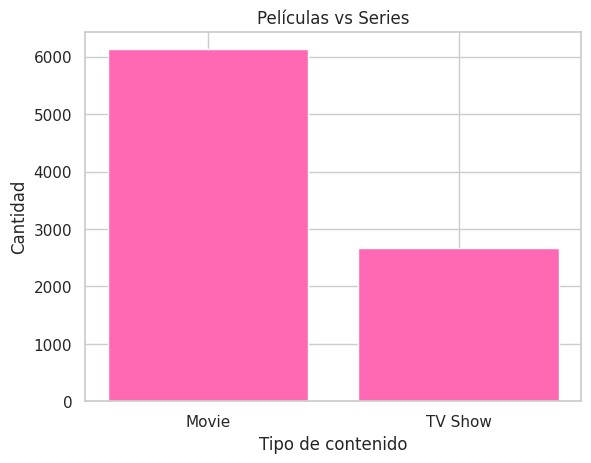

Predomina el contenido de películas, por lo que generalmente los usuarios tendrán más sugerencias de este contenido para visualizar en la aplicación.


In [24]:
#Distribución de tipos de contenido
conteo_type = df["type"].value_counts()

x = conteo_type.index
y = conteo_type.values

plt.bar(x, y, color="hotpink")
plt.title("Películas vs Series")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

print("Predomina el contenido de películas, por lo que generalmente los usuarios tendrán más sugerencias de este contenido para visualizar en la aplicación.")

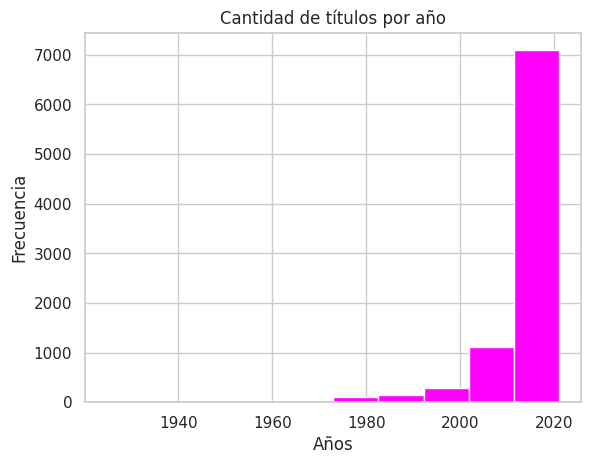

In [22]:
#Histograma de años de lanzamiento
plt.hist(df.release_year,color='magenta')

plt.xlabel('Años')
plt.ylabel('Frecuencia')
plt.title('Cantidad de títulos por año')
plt.show()
print("Hay notablemente más contenido en la década del 2020, probablemente producto de el uso más masivo de la plataforma.")

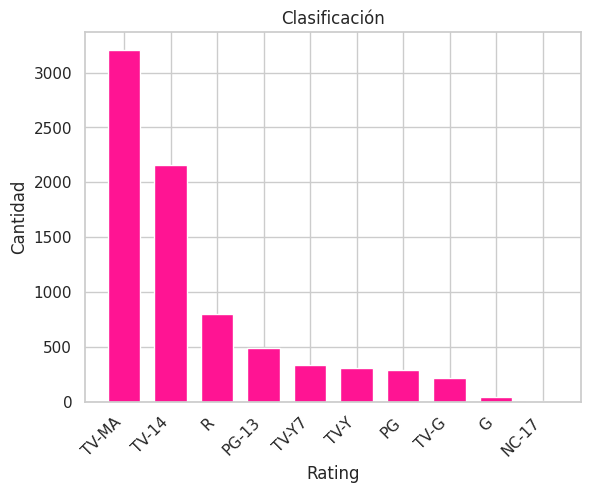

La clasificación más común es 'TV-MA', es decir, contenido para mayores de 17 años, por lo que es claro que la empresa se enfoca en el público más joven o jóven adulto


In [36]:
#Proporción de clasificaciones por edad
valid_ratings = ["TV-MA", "TV-14", "PG", "R", "G", "NC-17",
                 "TV-Y", "TV-Y7", "TV-G", "PG-13"]

df_clean = df[df["rating"].isin(valid_ratings)].copy()

conteo_rating = df_clean["rating"].value_counts()

x = conteo_rating.index
y = conteo_rating.values

plt.bar(x, y, color="deeppink", width=0.7)
plt.xticks(rotation=45, ha="right")
plt.title("Clasificación")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.show()

print("La clasificación más común es 'TV-MA', es decir, contenido para mayores de 17 años, por lo que es claro que la empresa se enfoca en el público más joven o jóven adulto")



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


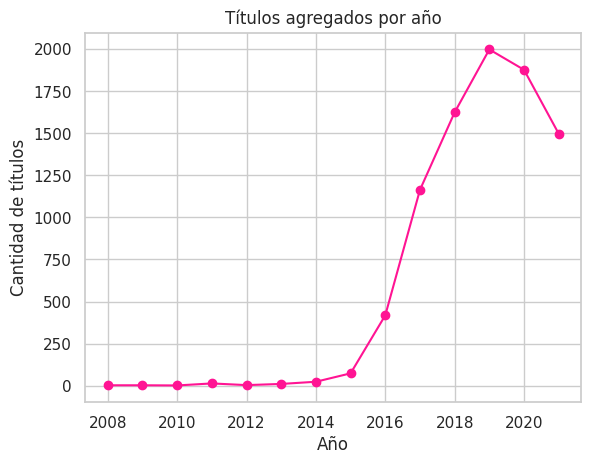

In [41]:
#Número de títulos agregados por año
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
conteo_anual = df.groupby(df["date_added"].dt.year).size()
x = conteo_anual.index
y = conteo_anual.values
plt.plot(x, y, marker="o", color="deeppink")
plt.title("Títulos agregados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de títulos")
plt.show()

print("En el año 2019 fue cuando se añadieron más títulos, la empresa empezó su expansión internacional en el año 2016, pero desde ese año se puede notar en el gráfico el aumento masivo de títulos agregados.")

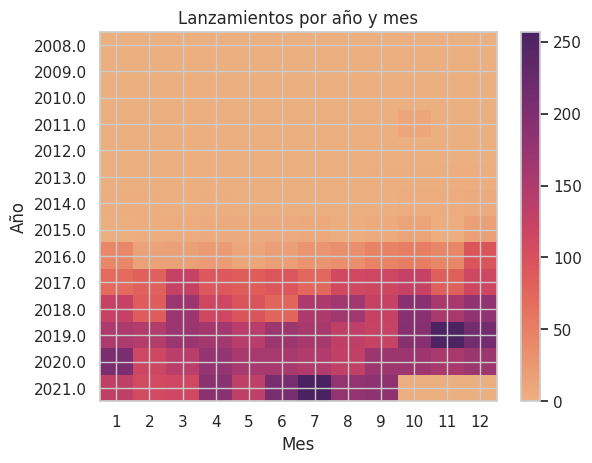

Hay meses con mayores lanzamientos que otros, pero también es algo que varía por años, se observa que alrededor de Julio y Noviembre se concentran más.


In [95]:
#Heatmap de lanzamientos por año y mes
import numpy as np
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
years = sorted(df["date_added"].dt.year.dropna().unique())
months = range(1, 13)

data = np.zeros((len(years), len(months)))
for i, y in enumerate(years):
    for j, m in enumerate(months):
        data[i, j] = df[(df["date_added"].dt.year==y) & (df["date_added"].dt.month==m)].shape[0]

plt.imshow(data, cmap='flare', aspect='auto')
plt.colorbar()
plt.xticks(range(len(months)), [str(m) for m in months])
plt.yticks(range(len(years)), [str(y) for y in years])
plt.xlabel('Mes')
plt.ylabel('Año')
plt.title('Lanzamientos por año y mes')
plt.show()

print("Hay meses con mayores lanzamientos que otros, pero también es algo que varía por años, se observa que alrededor de Julio y Noviembre se concentran más.")


/tmp/ipython-input-2411499628.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=genres, positions=positions, widths=0.5)


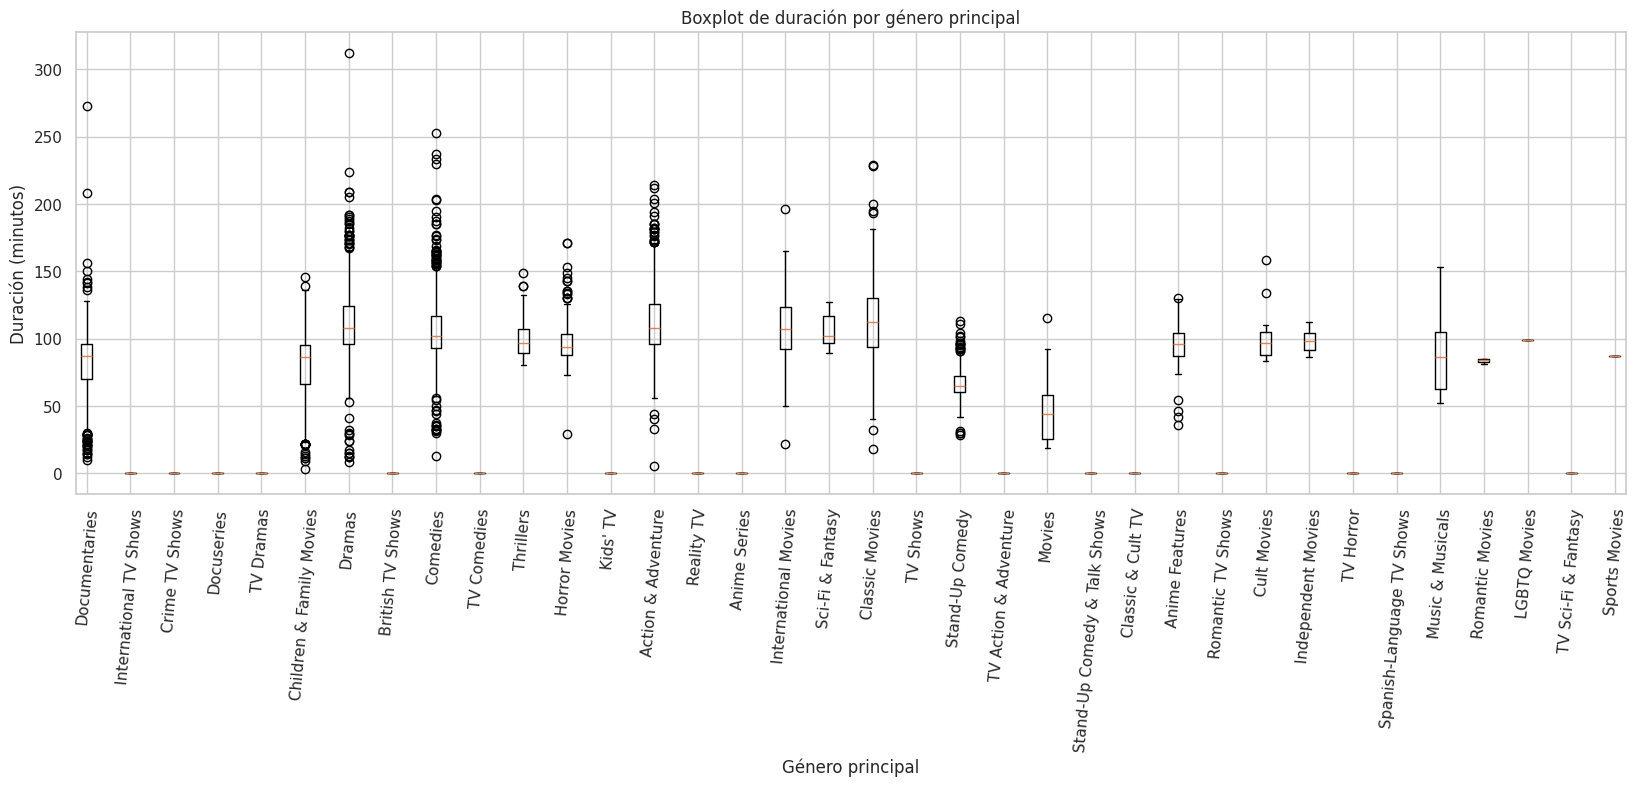

In [68]:
#Duración de películas por género
def parse_duration(d):
    if pd.isna(d):
        return None
    d = str(d)
    hours, minutes = 0, 0
    if 'h' in d:
        hours = int(d.split('h')[0].strip())
        d = d.split('h')[1]
    if 'm' in d:
        minutes = int(d.split('m')[0].strip())
    elif 'min' in d:
        minutes = int(d.replace('min','').strip())
    return hours*60 + minutes

df['duration_minutes'] = df['duration'].apply(parse_duration)
df['first_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())
genres = df['first_genre'].unique()
data_to_plot = [df[df['first_genre']==g]['duration_minutes'].dropna() for g in genres]

positions = range(1, len(genres)*2, 2)
plt.figure(figsize=(20,6))
plt.boxplot(data_to_plot, labels=genres, positions=positions, widths=0.5)
plt.xlabel('Género principal')
plt.ylabel('Duración (minutos)')
plt.title('Boxplot de duración por género principal')
plt.xticks(rotation=85)
plt.show()

print("Los géneros 'drama', 'acción y aventura' y 'películas clásicas' son los que concentran una mayor duración en sus películas y series. Dentro de un mismo género no se ve que haya mucha variación con respecto a las duraciones, salvo algunos casos excepcionales como 'documentales' o 'películas familiares'")



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



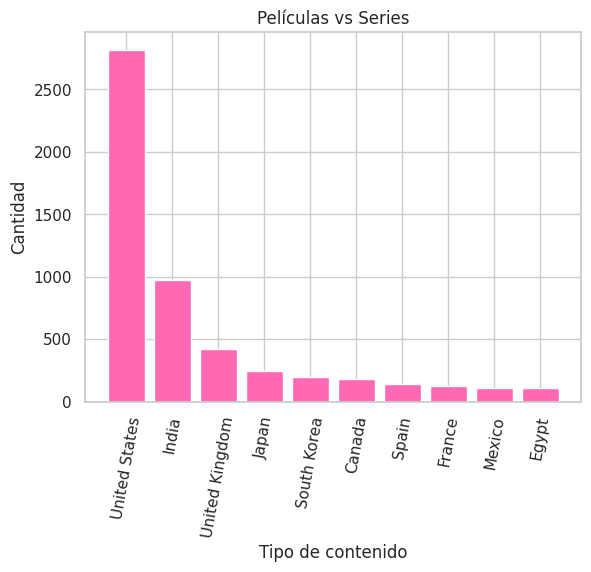

In [78]:
#Top 10 países con más producciones
conteo_type = df["country"].value_counts()
top10_countries = conteo_type.head(10)

x = top10_countries.index
y = top10_countries.values

plt.bar(x, y, color="hotpink")
plt.title("Películas vs Series")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")
plt.xticks(rotation=80)
plt.show()

print("La gran mayoría por lejos es de Estados Unidos, esto no es de extrañar ya que mundialmente predominan en la industria cinematográfica, esta lógica puede extrapolarse hasta el tercer lugar. Esta es una distribución totalmente esperada.")

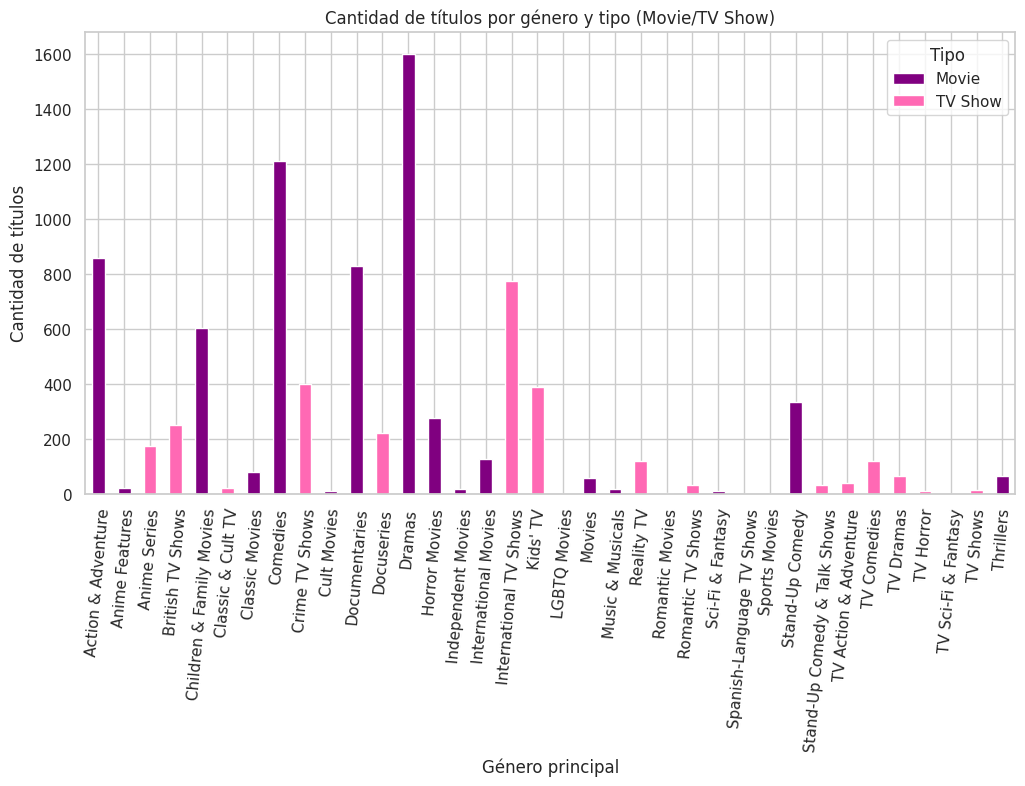

In [116]:
#Películas vs Series según género
df['first_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())
genre_type_counts = df.groupby(['first_genre', 'type']).size().unstack(fill_value=0)

colors = ['Purple', 'Hotpink']
genre_type_counts.plot(kind='bar', stacked=True, figsize=(12,6), color=colors)
plt.xlabel('Género principal')
plt.ylabel('Cantidad de títulos')
plt.title('Cantidad de títulos por género y tipo (Movie/TV Show)')
plt.xticks(rotation=85)
plt.legend(title='Tipo')
plt.show()

print("El género 'Drama' predomina en las películas. mientras que en las series predominan las series internacionales o para niños, aún así es difícil comparar, ya que la plataforma cuenta con muchas más películas que series.")

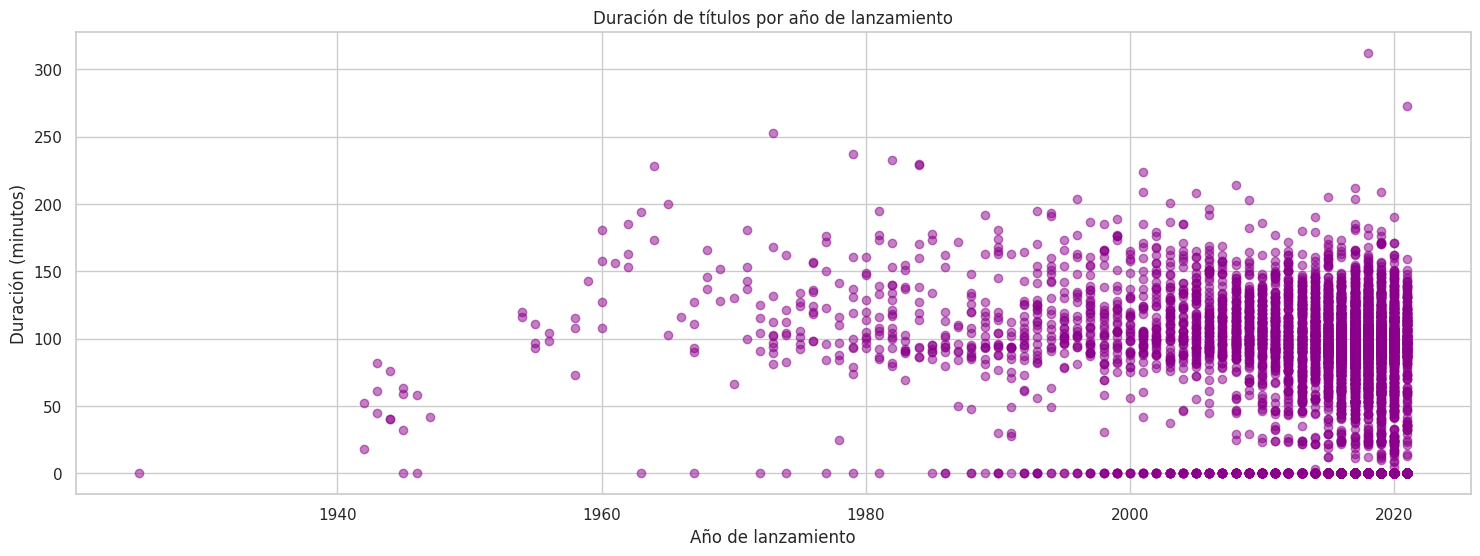

In [114]:
#Relación entre duración y año de lanzamiento
def parse_duration(d):
    if pd.isna(d):
        return None
    d = str(d)
    hours, minutes = 0, 0
    if 'h' in d:
        hours = int(d.split('h')[0].strip())
        d = d.split('h')[1]
    if 'm' in d:
        minutes = int(d.split('m')[0].strip())
    elif 'min' in d:
        minutes = int(d.replace('min','').strip())
    return hours*60 + minutes

df['duration_minutes'] = df['duration'].apply(parse_duration)
x=df['release_year']
y=df['duration_minutes']
# Crear scatterplot
plt.figure(figsize=(18,6))
plt.scatter(x, y, alpha=0.5, color='darkmagenta')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Duración (minutos)')
plt.title('Duración de títulos por año de lanzamiento')
plt.show()

print("Antiguamente la duración era relativamente corta, pero con los años se ha mantenido un estándar que pocas veces es modificado.")

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

# FIXME

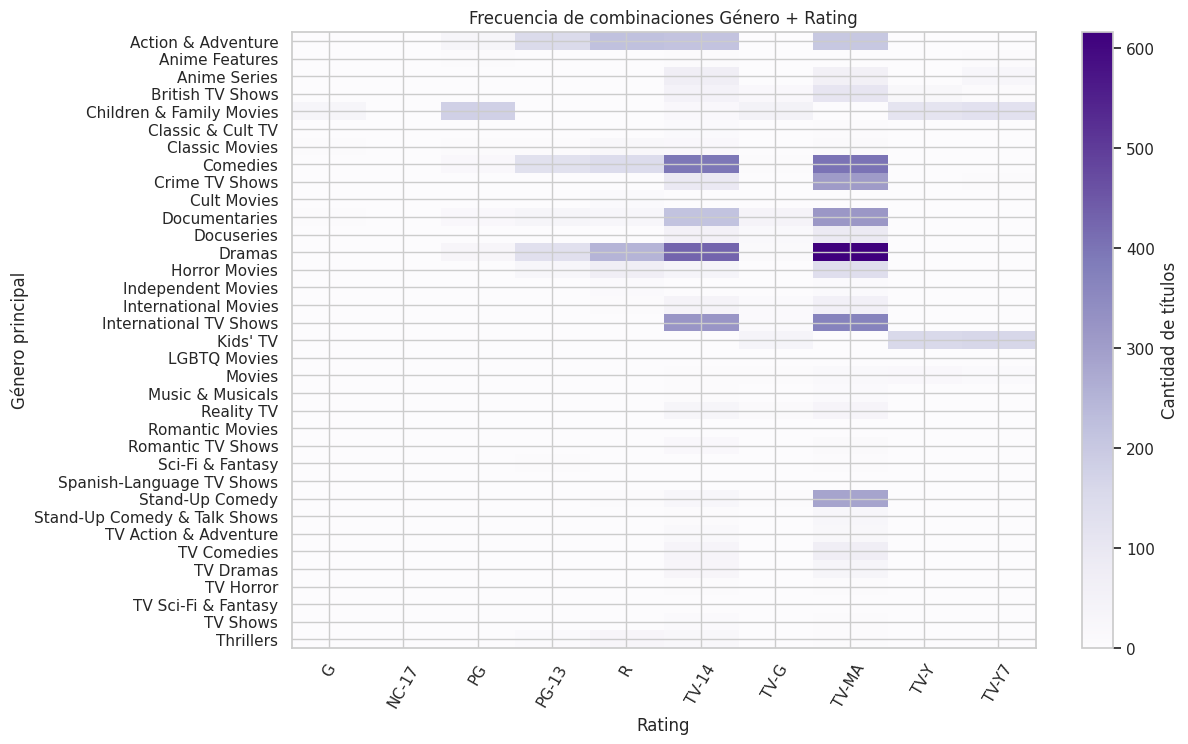

In [160]:
import numpy as np
valid_ratings = ["TV-MA", "TV-14", "PG", "R", "G", "NC-17",
                 "TV-Y", "TV-Y7", "TV-G", "PG-13"]

df_clean = df[df["rating"].isin(valid_ratings)].copy()
df['first_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())
genre_rating_counts = df.groupby(['first_genre', df_clean["rating"]]).size().unstack(fill_value=0)
data = genre_rating_counts.values
genres = genre_rating_counts.index
ratings = genre_rating_counts.columns


plt.figure(figsize=(12,8))
plt.imshow(data, cmap='Purples', aspect='auto')
plt.xticks(range(len(ratings)), ratings, rotation=60)
plt.yticks(range(len(genres)), genres)
plt.colorbar(label='Cantidad de títulos')
plt.xlabel('Rating')
plt.ylabel('Género principal')
plt.title('Combinaciones Género + Rating')
plt.show()

print("Dramas, comedia, acción y aventura son géneros más frecuentes para adultos, mientras que hay géneros específicos para el público familiar o infantil (el mismo nombre lo dice).")

